# Ανάλυση Δομής Γράφων με Clustering και Αναπαράσταση Κόμβων

Η εργασία αυτή στοχεύει στην εφαρμογή τεχνικών μηχανικής μάθησης για την ανάλυση της δομής γράφων. Αξιοποιούνται τεχνικές αναπαράστασης κόμβων όπως **Node2Vec** και **Graph Convolutional Networks (GCNs)**, ώστε να εξαχθούν διανυσματικές αναπαραστάσεις των κόμβων. Στη συνέχεια, εφαρμόζονται μέθοδοι ομαδοποίησης (**k-means**, **DBSCAN**) για την ανίχνευση κοινοτήτων και τη διερεύνηση της εσωτερικής δομής των γράφων.

Χρησιμοποιούμε τα datasets **Cora** και **Citeseer**, τα οποία περιλαμβάνουν επιστημονικές δημοσιεύσεις ως κόμβους και σχέσεις αναφορών ως ακμές.

## Imports

In [1]:
from torch_geometric.datasets import Planetoid
import torch
from torch.nn import Dropout, BatchNorm1d
import torch.nn.functional as F
from torch_geometric.nn import GCNConv,SAGEConv
import torch_geometric.transforms as T
import networkx as nx
from node2vec import Node2Vec
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score,silhouette_score
from sklearn.manifold import TSNE
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA


c:\Users\Dell\anaconda3\envs\node2vec-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Φόρτωση Αρχείων 

In [2]:
cora = Planetoid(root='data/Planetoid', name='Cora')[0]
citeseer = Planetoid(root='data/Planetoid', name='Citeseer')[0]

# Μετατροπή σε NetworkX γράφους (undirected)
G_cora = to_networkx(cora, to_undirected=True)
G_citeseer = to_networkx(citeseer, to_undirected=True)

In [4]:
def print_graph_info(data, name):
    print(f"\nDataset: {name}")
    print(f"Nodes: {data.num_nodes}")
    print(f"Edges: {data.num_edges}")
    print(f"Features per node: {data.num_node_features}")
    print(f"Number of classes: {data.y.max().item() + 1}")
    print(f"Edge index shape: {data.edge_index.shape}")

In [ ]:
print_graph_info(cora, "Cora")
print_graph_info(citeseer, "Citeseer")


Dataset: Cora
Nodes: 2708
Edges: 10556
Features per node: 1433
Number of classes: 7
Edge index shape: torch.Size([2, 10556])

Dataset: Citeseer
Nodes: 3327
Edges: 9104
Features per node: 3703
Number of classes: 6
Edge index shape: torch.Size([2, 9104])


## Οπτικοποίηση

In [23]:
def draw_full_graph(G, title):
    plt.figure(figsize=(12, 12))
    nx.draw(G,
            node_size=30,
            with_labels=False,
            edge_color="gray",
            alpha=0.7)
    plt.title(title)
    plt.axis('off')
    plt.show()


Cora

Ένα δημοφιλές dataset για ανάλυση γράφων και ταξινόμηση εγγράφων. Αποτελείται από 2708 επιστημονικά άρθρα (κόμβοι), καθένα με χαρακτηριστικά βασισμένα σε λέξεις, και 5429 ακμές που αντιπροσωπεύουν αναφορές μεταξύ άρθρων. Κάθε άρθρο ανήκει σε μία από 7 κατηγορίες.

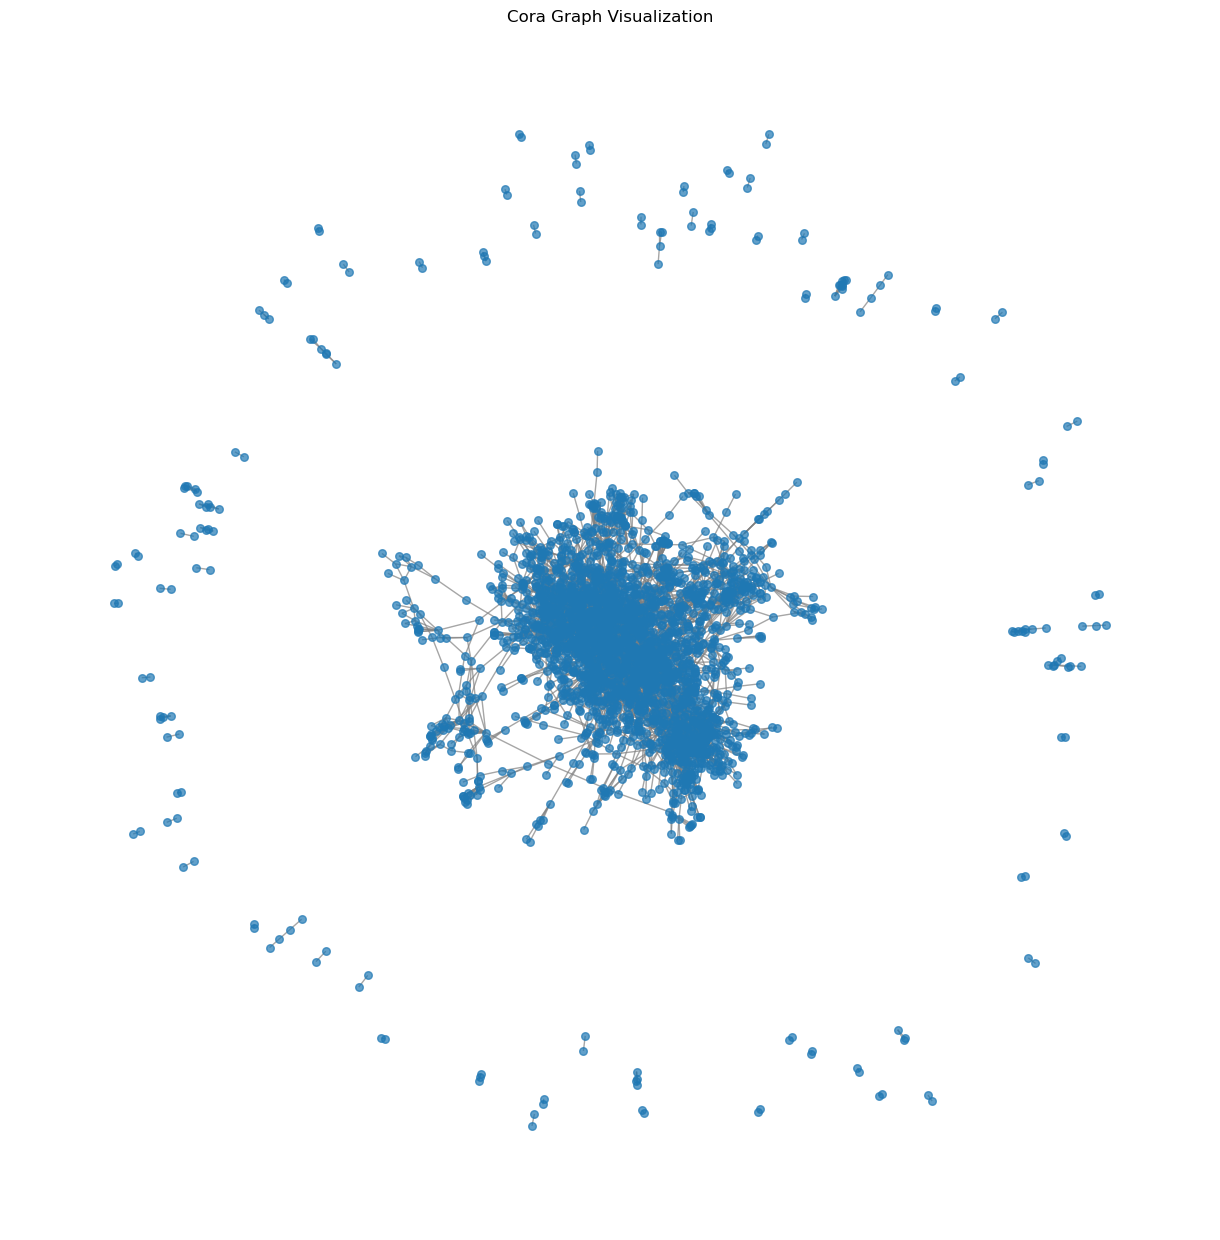

In [24]:
draw_full_graph(G_cora, "Cora Graph Visualization")

Citeseer

Ένα άλλο dataset επιστημονικών άρθρων με 3327 κόμβους και 4732 ακμές. Όπως και το Cora, οι κόμβοι είναι έγγραφα με χαρακτηριστικά βασισμένα σε λέξεις και οι ακμές είναι παραπομπές. Τα άρθρα κατηγοριοποιούνται σε 6 διαφορετικές κλάσεις.

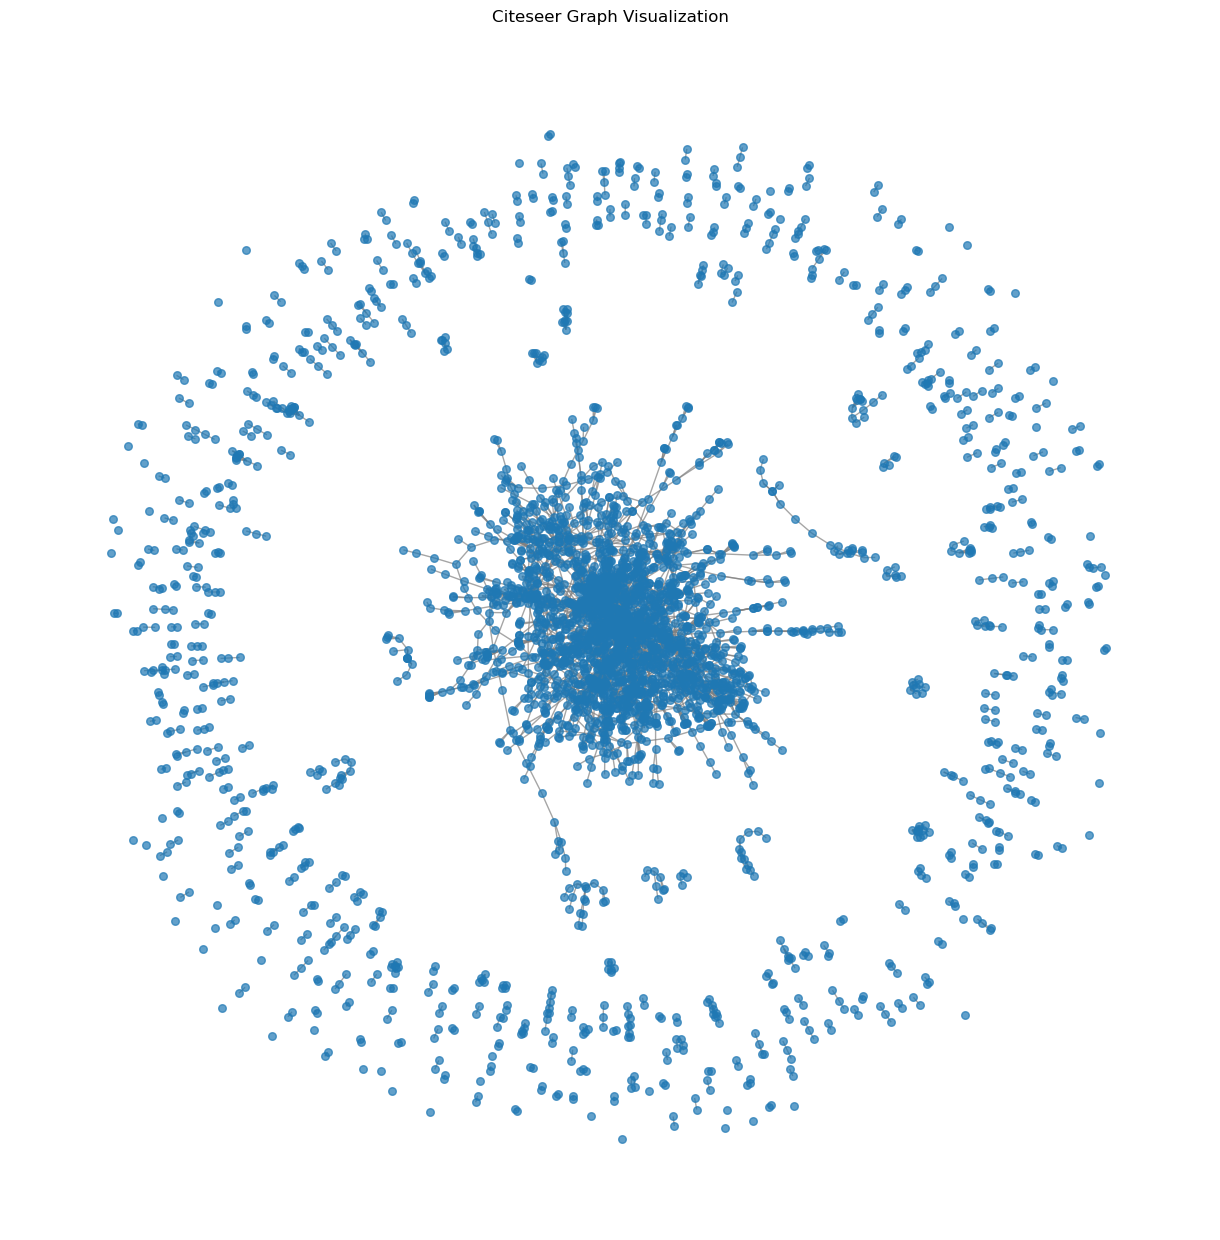

In [25]:
draw_full_graph(G_citeseer, "Citeseer Graph Visualization")

### Πλήθος Labels

In [5]:
labelscora = cora.y.tolist()
print(set(labelscora))

{0, 1, 2, 3, 4, 5, 6}


In [6]:
labelscite = citeseer.y.tolist()
print(set(labelscite))

{0, 1, 2, 3, 4, 5}


# Functions

In [ ]:
def scores(name, true_labels, predicted_labels, embeddings):
    print(f"For {name} method the metrics are:\n")
    
    ari = adjusted_rand_score(true_labels, predicted_labels)
    nmi = normalized_mutual_info_score(true_labels, predicted_labels)
    sil_score = silhouette_score(embeddings, predicted_labels)

    print(f"Adjusted Rand Index (ARI): {ari:.2f}")
    print(f"Normalized Mutual Information (NMI): {nmi:.2f}")
    print(f"Silhouette Score: {sil_score:.2f}",)
    print('\n')

def scores2(method,type,true_labels,predicted_labels,embeddings):
    ari =round(adjusted_rand_score(true_labels, predicted_labels),2) 
    nmi = round(normalized_mutual_info_score(true_labels, predicted_labels),2)
    sil_score = round(silhouette_score(embeddings, predicted_labels),2)
    return [method,type,sil_score,ari,nmi]


def plotResults(name,methods,embeddings_list,predictions_list):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    fig.suptitle(name, fontsize=16)
    
    for i in range(3):
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        reduced = tsne.fit_transform(embeddings_list[i])
        axes[i].scatter(reduced[:, 0], reduced[:, 1], c=predictions_list[i], cmap='viridis', s=30)
        axes[i].set_title(f'{methods[i]} Embedding')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
    plt.show()


# Models

## Graph Convolutional Network

In [165]:
class GCN(torch.nn.Module):
    def __init__(self,in_channel,hidden_channel,out_channel):
        super().__init__()
        self.conv1=GCNConv(in_channel,128)
        self.conv2=GCNConv(128,64)
        self.conv3=GCNConv(64,out_channel)
        

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x=self.conv3(x,edge_index)

        return x

In [169]:
def trainingGCN(data,out_channels):
    model=GCN(data.num_node_features,128,out_channels)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    # Extract embeddings (before final layer, optional)
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        embeddings = out.cpu().numpy()
    return embeddings

## Graph Sage

In [ ]:
class GraphSageModel(torch.nn.Module):
    def __init__(self,in_channel,hidden_channel,out_channel):
        super().__init__()
        self.conv1=SAGEConv(in_channel,128)
        self.conv2=SAGEConv(128,64)
        self.conv3=SAGEConv(64,out_channel)
        

    def forward(self, x, edge_index):
            x = self.conv1(x, edge_index)
            x = F.relu(x)
            x = self.conv2(x, edge_index)
            x = F.relu(x)
            x=self.conv3(x,edge_index)

            return x

In [148]:
def trainingSage(data,out_channels):
    model=GraphSageModel(data.num_node_features,128,out_channels)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    # Extract embeddings (before final layer, optional)
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        embeddings = out.cpu().numpy()
    return embeddings

# CORA

In [211]:
results_cora=pd.DataFrame(columns=["Embeddings type","Clustering ","Silhouette Score","ARI","NMI"])
methods=["Node2vec",'GCN',"Graph Sage"]

## Embeddings

In [182]:
node2vec = Node2Vec(G_cora, dimensions=128, walk_length=30, num_walks=200, p=1, q=1, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)
nodes=list(G_cora.nodes())
embeddingsN2v = np.array([model.wv[str(node)] for node in nodes])
embeddingsGCN=trainingGCN(cora,7)
embeddingsSage=trainingSage(cora,7)


Computing transition probabilities:   0%|          | 0/2708 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 2708/2708 [00:03<00:00, 781.20it/s] 


## Clustering

### Kmeans


In [ ]:
true_labels = cora.y.numpy()
kmeans=KMeans(n_clusters=7,random_state=42)


In [ ]:
predictionsN2v=kmeans.fit_predict(embeddingsN2v)
predictionsGCN=kmeans.fit_predict(embeddingsGCN)
predictionsSage=kmeans.fit_predict(embeddingsSage)


In [278]:
predictions_list=[]
predictions_list=[predictionsN2v,predictionsGCN,predictionsSage]
embeddings_list=[embeddingsN2v,embeddingsGCN,embeddingsGCN]

In [212]:
results_cora.loc[len(results_cora)]=scores2("kmeans","Node2Vec",true_labels,predictionsN2v,embeddingsN2v)
results_cora.loc[len(results_cora)]=scores2("kmeans","GCN",true_labels,predictionsGCN,embeddingsGCN)
results_cora.loc[len(results_cora)]=scores2("kmeans","Graph Sage",true_labels,predictionsSage,embeddingsSage)

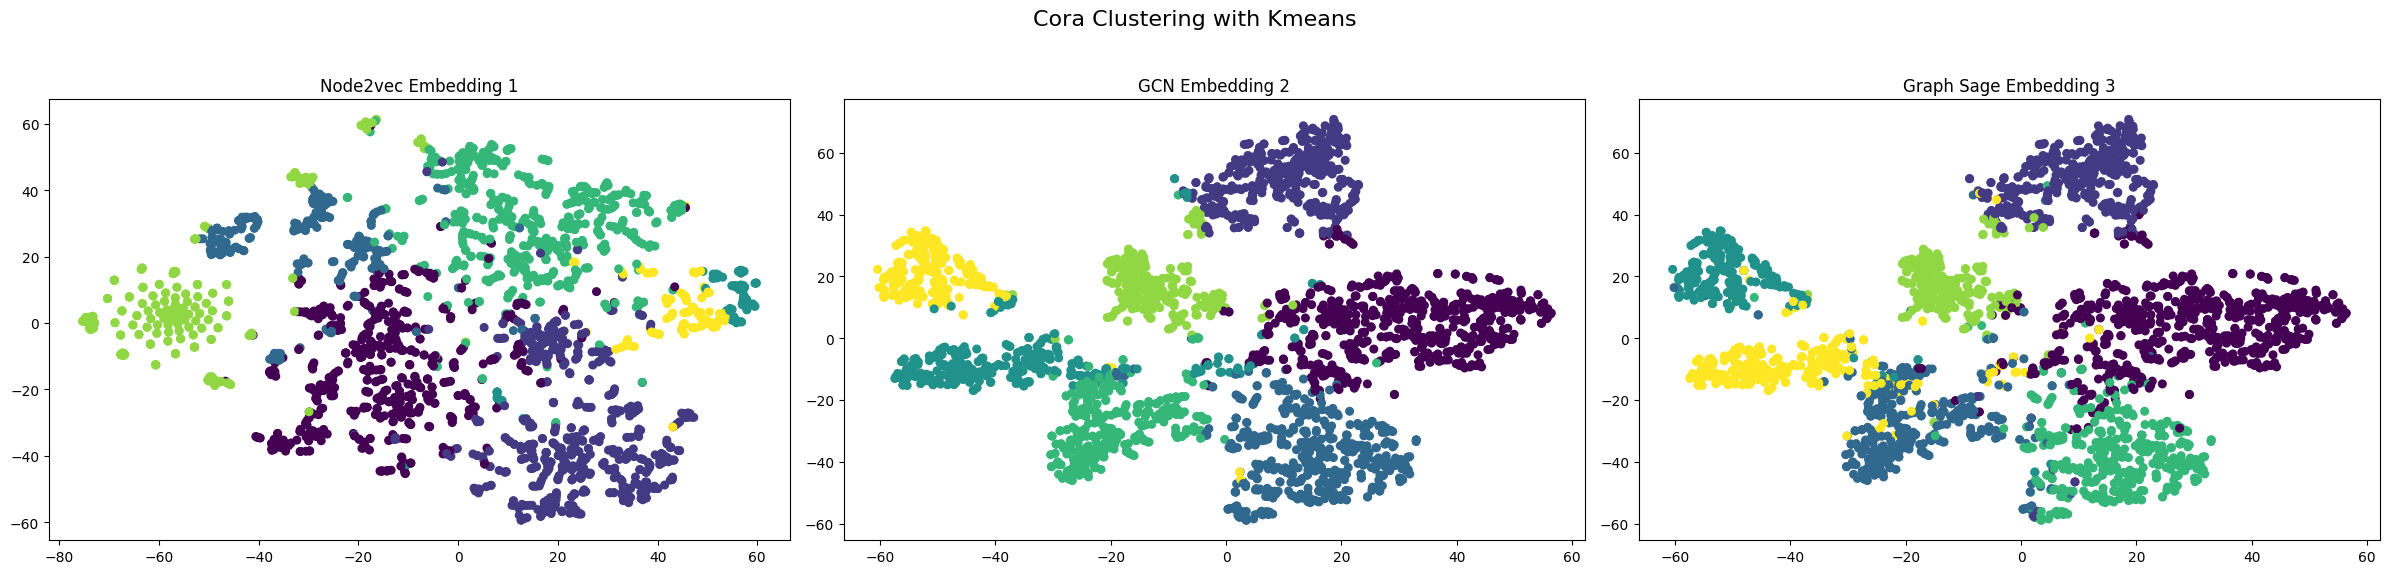

In [206]:
plotResults(name="Cora Clustering with Kmeans",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

### DBSCAN

Σύμφωνα με τον εμπειρικό κανόνα min_samples>dimensions+1.Για την δική μας περίπτωση θα επιλέξουμε 129 και 8.
Για να βρούμε την βέλτιστη τιμη της παραμέτρου eps θα ακολουθήσουμε τα εξής βήματα.

1:Υπολογισμός των αποστάσεων για τους k-nearest neighbors για k=min_samples-1.

2:Ταξινόμηση αυτών των αποστάσεων.

3:Δημιουργία γραφήματος αποστάσεων για να βρούμε το γόνατο (το σημείο όπου οι αποστάσεις αυξάνονται απότομα).

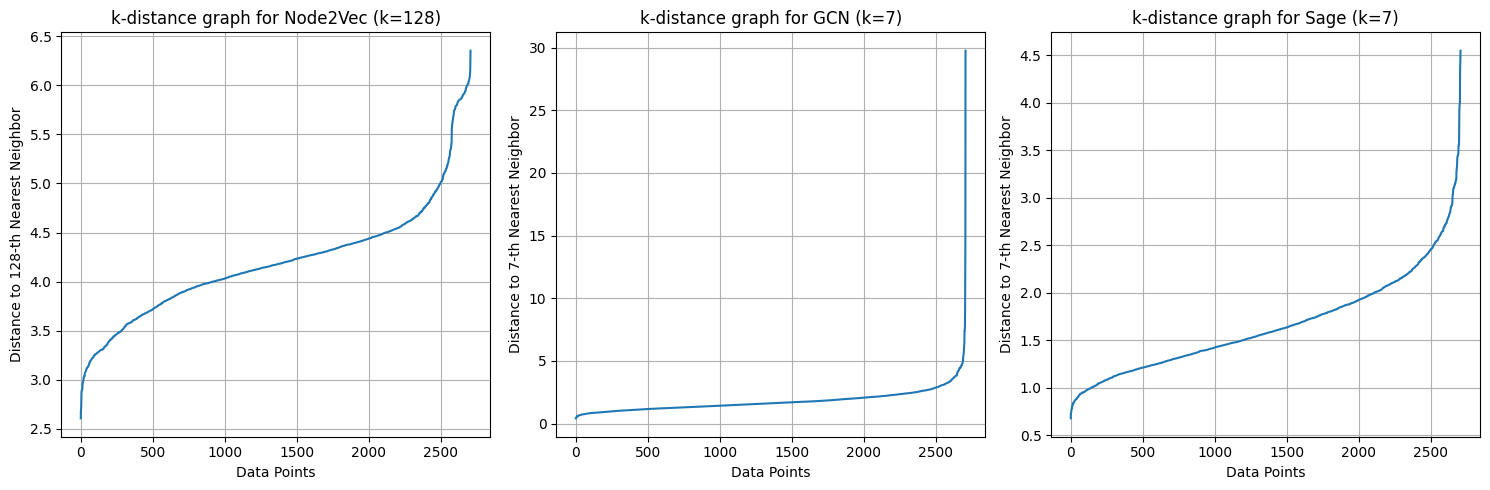

In [214]:
# Node2Vec
k1 = 128
neighbor1 = NearestNeighbors(n_neighbors=k1)
neighbor1.fit(embeddingsN2v)
distances1, indices1 = neighbor1.kneighbors(embeddingsN2v)
k_distances1 = distances1[:, -1]
k_distances_sorted1 = np.sort(k_distances1)

# GCN - πρώτο γράφημα
k2 = 7
neighbor2 = NearestNeighbors(n_neighbors=k2)
neighbor2.fit(embeddingsGCN)
distances2, indices2 = neighbor2.kneighbors(embeddingsGCN)
k_distances2 = distances2[:, -1]
k_distances_sorted2 = np.sort(k_distances2)

# Graph sage 
k3 = 7
neighbor3 = NearestNeighbors(n_neighbors=k3)
neighbor3.fit(embeddingsSage)
distances3, indices3 = neighbor3.kneighbors(embeddingsSage)
k_distances3 = distances3[:, -1]
k_distances_sorted3 = np.sort(k_distances3)

# Σχεδίαση
plt.figure(figsize=(15, 5))

# Node2Vec
plt.subplot(1, 3, 1)
plt.plot(k_distances_sorted1)
plt.xlabel("Data Points")
plt.ylabel(f"Distance to {k1}-th Nearest Neighbor")
plt.title(f"k-distance graph for Node2Vec (k={k1})")
plt.grid(True)

# GCN - Πρώτο
plt.subplot(1, 3, 2)
plt.plot(k_distances_sorted2)
plt.xlabel("Data Points")
plt.ylabel(f"Distance to {k2}-th Nearest Neighbor")
plt.title(f"k-distance graph for GCN (k={k2})")
plt.grid(True)

# GCN - Δεύτερο
plt.subplot(1, 3, 3)
plt.plot(k_distances_sorted3)
plt.xlabel("Data Points")
plt.ylabel(f"Distance to {k3}-th Nearest Neighbor")
plt.title(f"k-distance graph for Sage (k={k3})")
plt.grid(True)

plt.tight_layout()
plt.show()


In [219]:
dbscan1= DBSCAN(eps=4.5 , min_samples=129)
dbscan2=DBSCAN(eps=5,min_samples=8)
dbscan3=DBSCAN(eps=2,min_samples=8)


predictionsN2v2=dbscan1.fit_predict(embeddingsN2v)
predictionsGCN2=dbscan2.fit_predict(embeddingsGCN)
predictionsSage2=dbscan3.fit_predict(embeddingsSage)

predictions_list.clear()
predictions_list=[predictionsN2v2,predictionsGCN2,predictionsSage2]

In [222]:
results_cora.loc[len(results_cora)]=scores2("DBSCAN","Node2Vec",true_labels,predictionsN2v2,embeddingsN2v)
results_cora.loc[len(results_cora)]=scores2("DBSCAN","GCN",true_labels,predictionsGCN2,embeddingsGCN)
results_cora.loc[len(results_cora)]=scores2("DBSCAN","Graph Sage",true_labels,predictionsSage2,embeddingsSage)

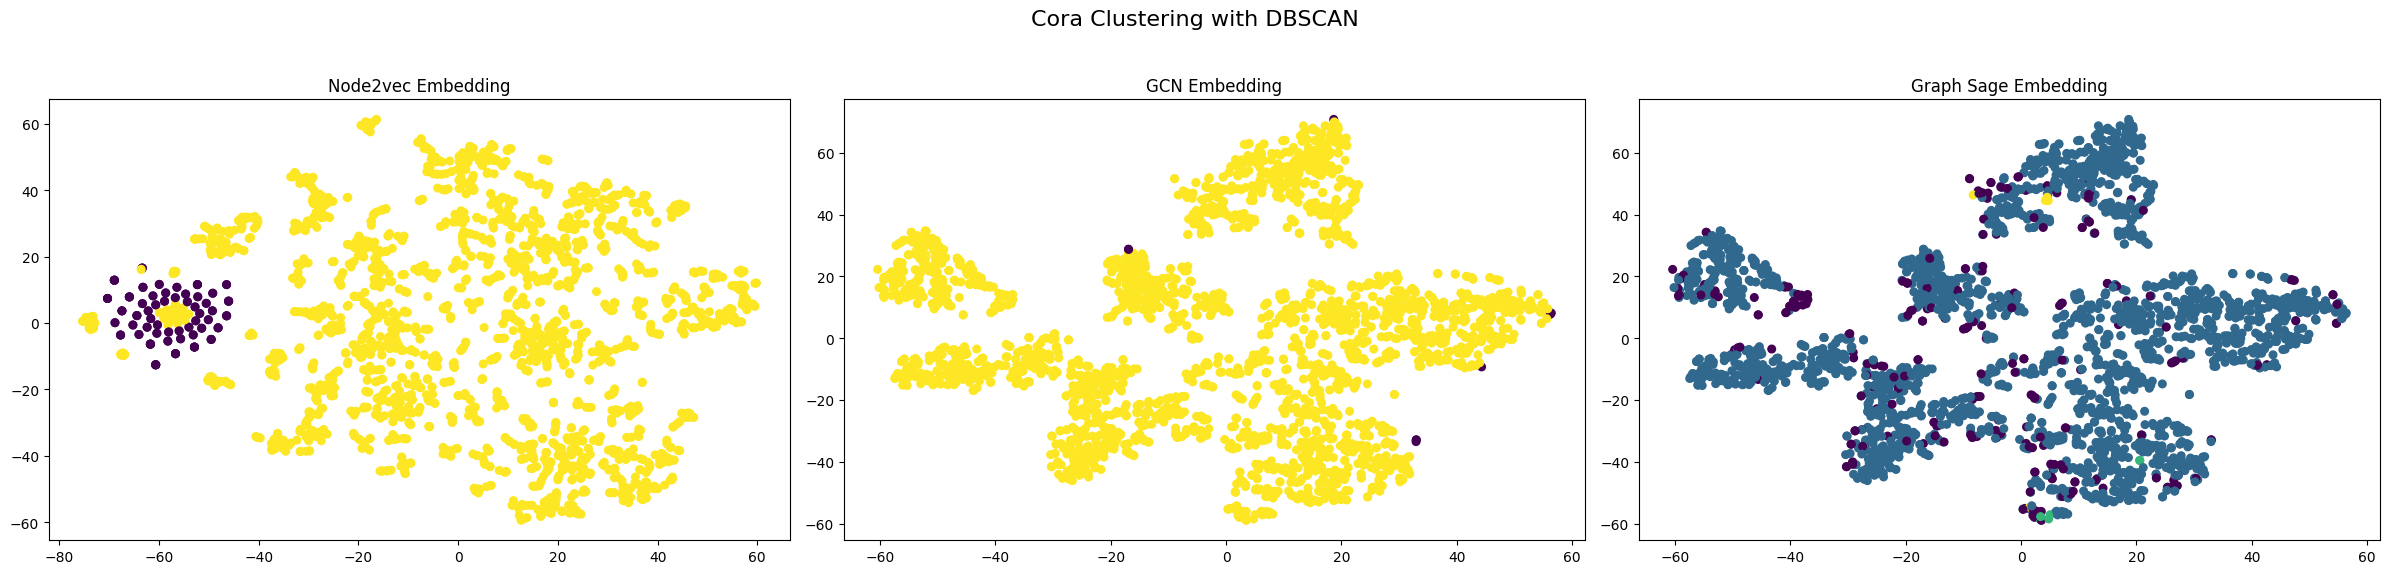

In [221]:
plotResults(name="Cora Clustering with DBSCAN",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

### Spectral

In [ ]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(n_clusters=7, affinity='nearest_neighbors', random_state=42)

In [224]:
predictionsN2v3=sc.fit_predict(embeddingsN2v)
predictionsGCN3=sc.fit_predict(embeddingsGCN)
predictionsSage3=sc.fit_predict(embeddingsSage)
predictions_list.clear()
predictions_list=[predictionsN2v3,predictionsGCN3,predictionsSage3]

In [226]:
results_cora.loc[len(results_cora)]=scores2("Spectral","Node2Vec",true_labels,predictionsN2v3,embeddingsN2v)
results_cora.loc[len(results_cora)]=scores2("Spectral","GCN",true_labels,predictionsGCN3,embeddingsGCN)
results_cora.loc[len(results_cora)]=scores2("Spectral","Graph Sage",true_labels,predictionsSage3,embeddingsSage)

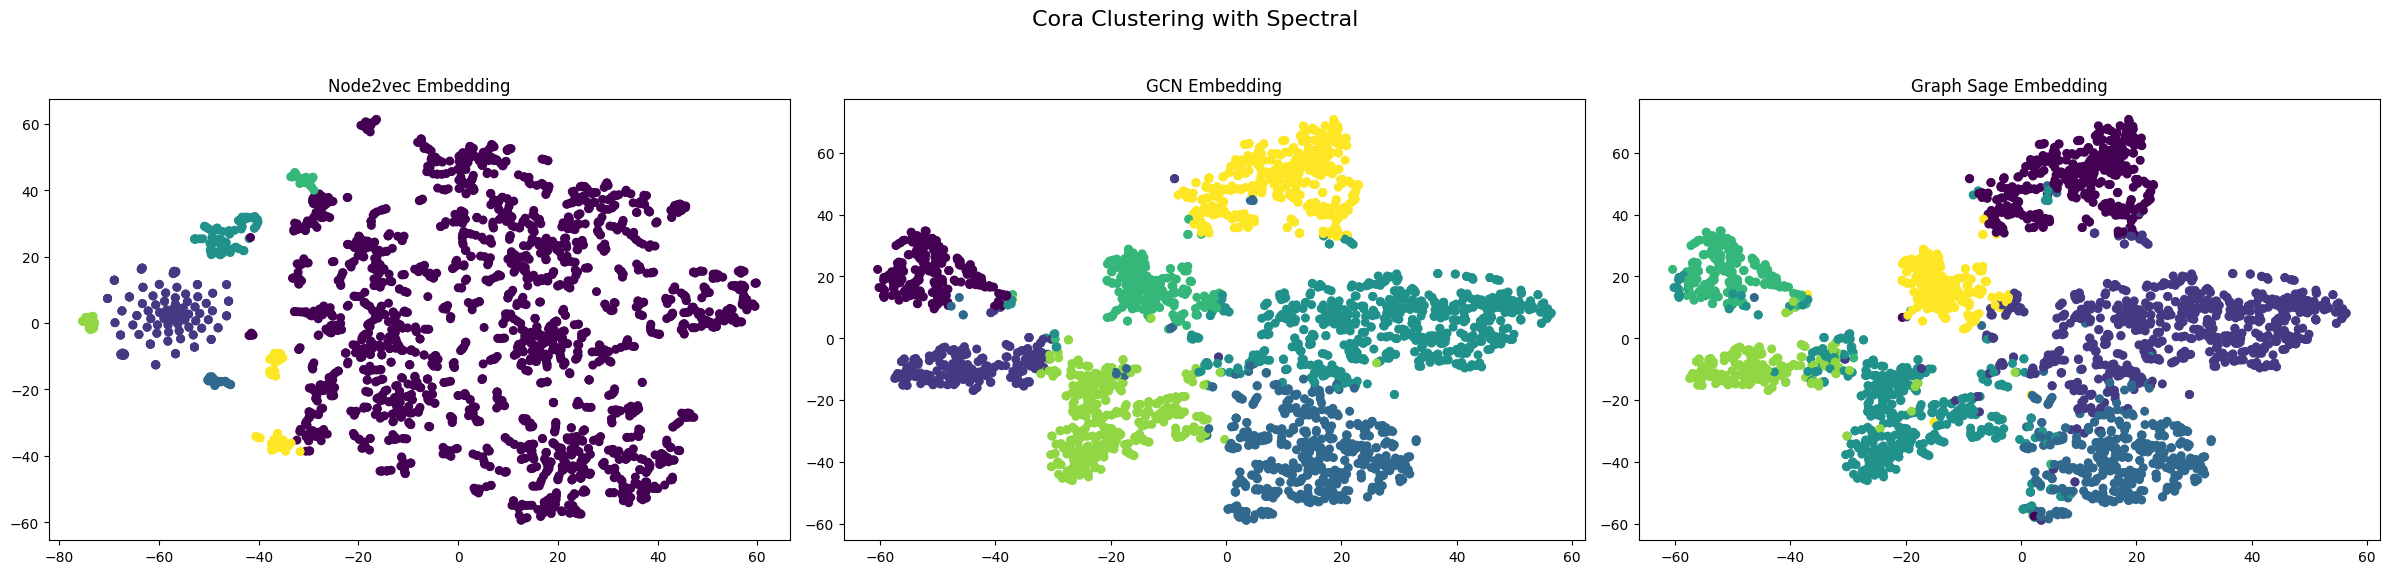

In [227]:
plotResults(name="Cora Clustering with Spectral",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

### Gaussian Mixture Model

In [229]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=7, covariance_type='full', random_state=42)

In [230]:
predictionsN2v4=gmm.fit_predict(embeddingsN2v)
predictionsGCN4=gmm.fit_predict(embeddingsGCN)
predictionsSage4=gmm.fit_predict(embeddingsSage)

predictions_list.clear()
predictions_list=[predictionsN2v4,predictionsGCN4,predictionsSage4]

In [233]:
results_cora.loc[len(results_cora)]=scores2("GMM","Node2Vec",true_labels,predictionsN2v4,embeddingsN2v)
results_cora.loc[len(results_cora)]=scores2("GMM","GCN",true_labels,predictionsGCN4,embeddingsGCN)
results_cora.loc[len(results_cora)]=scores2("GMM","Graph Sage",true_labels,predictionsSage4,embeddingsSage)

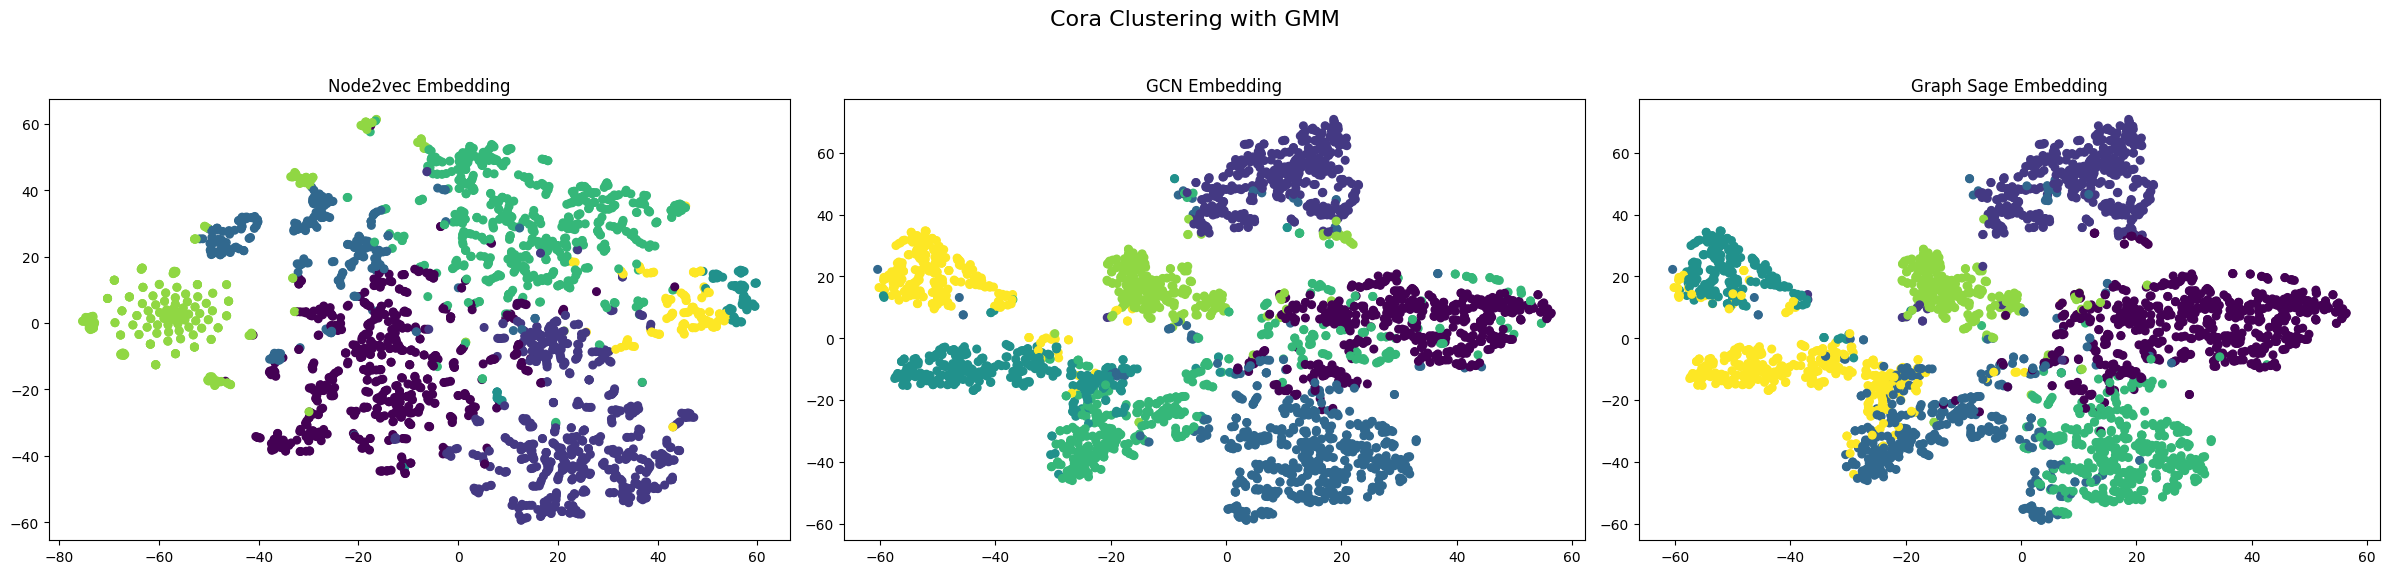

In [232]:
plotResults(name="Cora Clustering with GMM",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

# Citeseer

In [236]:
results_citeseer=pd.DataFrame(columns=["Embeddings type","Clustering ","Silhouette Score","ARI","NMI"])

## Embeddings

In [ ]:
node2vec = Node2Vec(G_citeseer, dimensions=128, walk_length=30, num_walks=200, p=1, q=1, workers=4)
model = node2vec.fit(window=10, min_count=1, batch_words=4)
nodes=list(G_citeseer.nodes())
embeddingsN2vCite= np.array([model.wv[str(node)] for node in nodes])
embeddingsGCN_cite=trainingGCN(citeseer,6)
embeddingsSageCite=trainingSage(citeseer,6)

Computing transition probabilities: 100%|██████████| 3327/3327 [00:00<00:00, 5563.34it/s]


## Clustering

### Kmeans

In [248]:
true_labels = citeseer.y.numpy()
kmeans=KMeans(n_clusters=6,random_state=42)
embeddings_list.clear()
predictions_list.clear()

In [249]:
predictionsN2vcite=kmeans.fit_predict(embeddingsN2vCite)
predictionsGCNcite=kmeans.fit_predict(embeddingsGCN_cite)
predictionsSagecite=kmeans.fit_predict(embeddingsSageCite)
embeddings_list=[embeddingsN2vCite,embeddingsGCN_cite,embeddingsSageCite]
predictions_list=[predictionsN2vcite,predictionsGCNcite,predictionsSagecite]


In [251]:
results_citeseer.loc[len(results_citeseer)]=scores2("kmeans","Node2Vec",true_labels,predictionsN2vcite,embeddingsN2vCite)
results_citeseer.loc[len(results_citeseer)]=scores2("kmeans","GCN",true_labels,predictionsGCNcite,embeddingsGCN_cite)
results_citeseer.loc[len(results_citeseer)]=scores2("kmeans","Graph Sage",true_labels,predictionsSagecite,embeddingsSageCite)

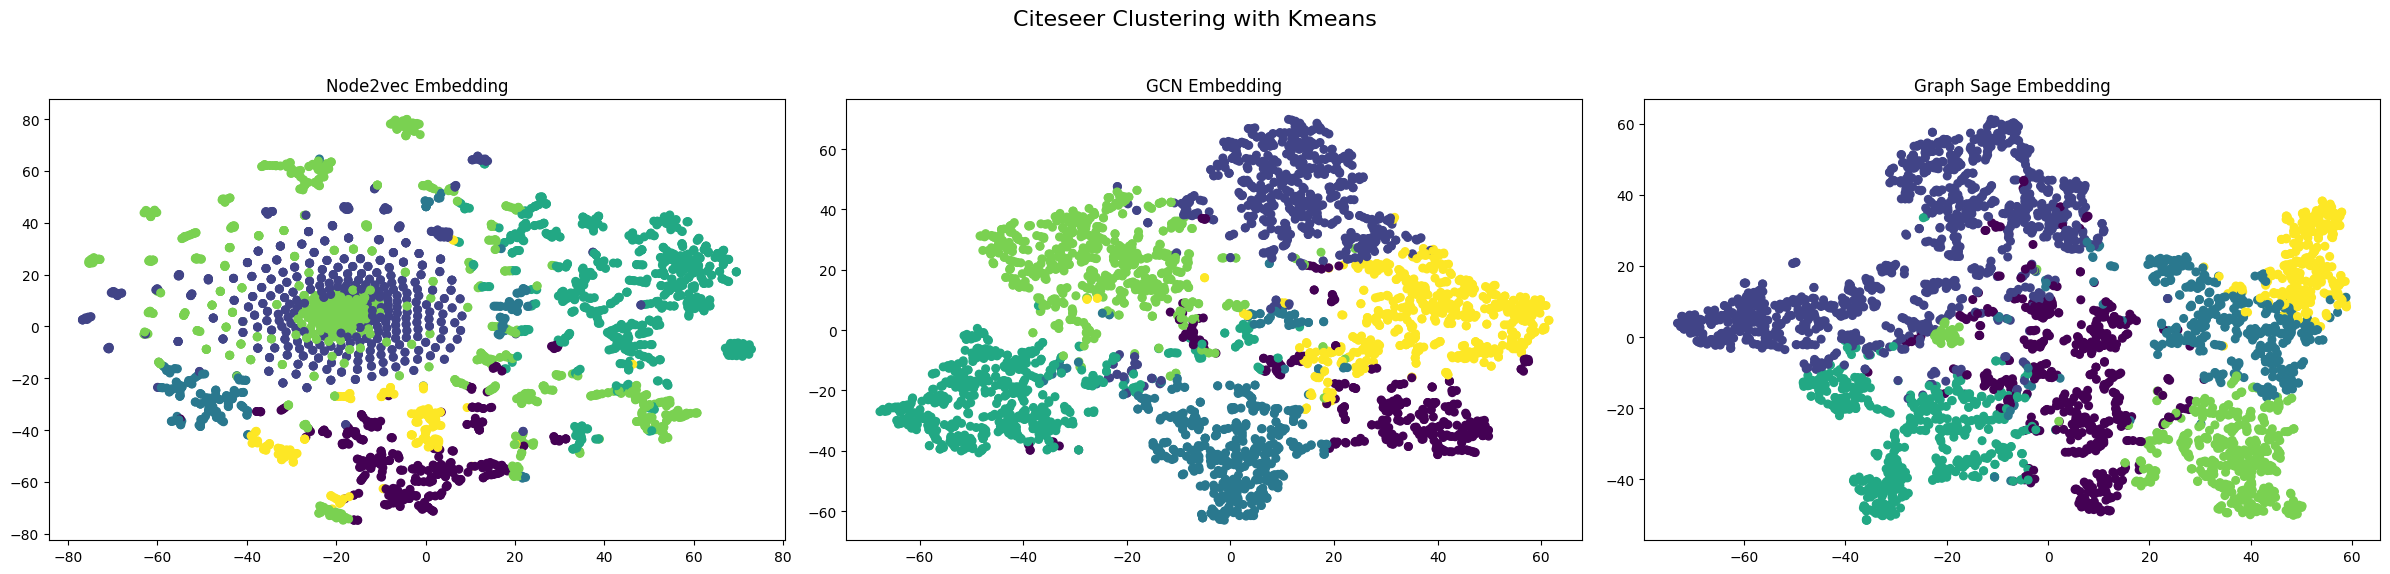

In [252]:
plotResults(name="Citeseer Clustering with Kmeans",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

### DBSCAN

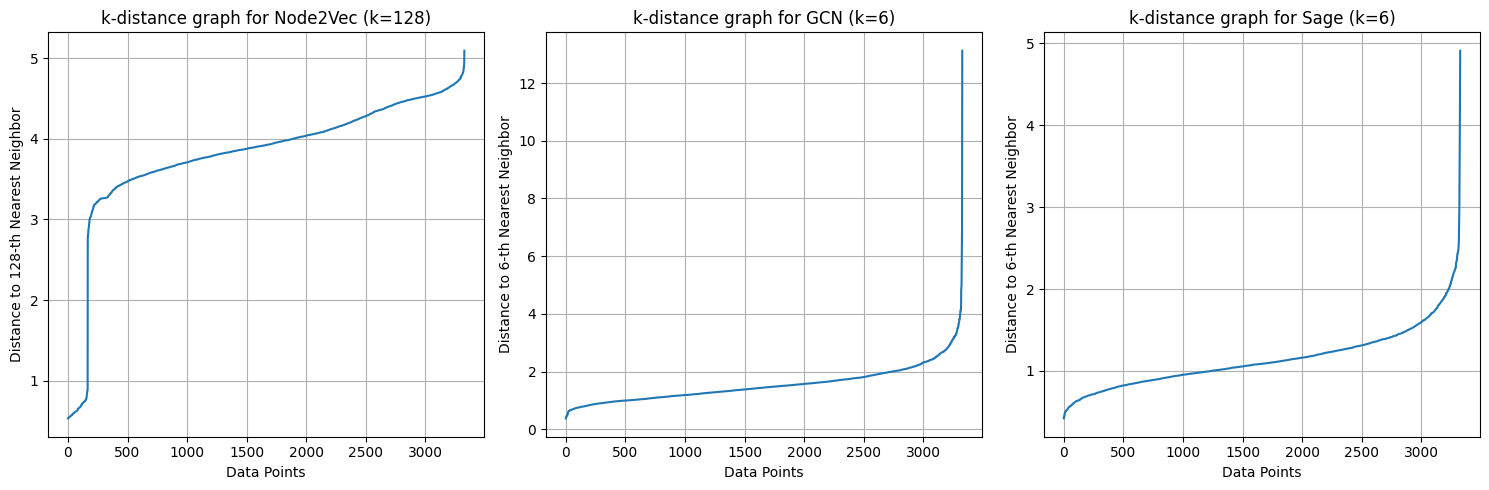

In [254]:
# Node2Vec
k1 = 128
neighbor1 = NearestNeighbors(n_neighbors=k1)
neighbor1.fit(embeddingsN2vCite)
distances1, indices1 = neighbor1.kneighbors(embeddingsN2vCite)
k_distances1 = distances1[:, -1]
k_distances_sorted1 = np.sort(k_distances1)

# GCN - πρώτο γράφημα
k2 = 6
neighbor2 = NearestNeighbors(n_neighbors=k2)
neighbor2.fit(embeddingsGCN_cite)
distances2, indices2 = neighbor2.kneighbors(embeddingsGCN_cite)
k_distances2 = distances2[:, -1]
k_distances_sorted2 = np.sort(k_distances2)

# Graph sage 
k3 = 6
neighbor3 = NearestNeighbors(n_neighbors=k3)
neighbor3.fit(embeddingsSageCite)
distances3, indices3 = neighbor3.kneighbors(embeddingsSageCite)
k_distances3 = distances3[:, -1]
k_distances_sorted3 = np.sort(k_distances3)

# Σχεδίαση
plt.figure(figsize=(15, 5))

# Node2Vec
plt.subplot(1, 3, 1)
plt.plot(k_distances_sorted1)
plt.xlabel("Data Points")
plt.ylabel(f"Distance to {k1}-th Nearest Neighbor")
plt.title(f"k-distance graph for Node2Vec (k={k1})")
plt.grid(True)

# GCN - Πρώτο
plt.subplot(1, 3, 2)
plt.plot(k_distances_sorted2)
plt.xlabel("Data Points")
plt.ylabel(f"Distance to {k2}-th Nearest Neighbor")
plt.title(f"k-distance graph for GCN (k={k2})")
plt.grid(True)

# GCN - Δεύτερο
plt.subplot(1, 3, 3)
plt.plot(k_distances_sorted3)
plt.xlabel("Data Points")
plt.ylabel(f"Distance to {k3}-th Nearest Neighbor")
plt.title(f"k-distance graph for Sage (k={k3})")
plt.grid(True)

plt.tight_layout()
plt.show()

In [257]:
dbscan1= DBSCAN(eps=3 , min_samples=129)
dbscan2=DBSCAN(eps=2,min_samples=7)
dbscan3=DBSCAN(eps=1.5,min_samples=7)


predictionsN2vcite2=dbscan1.fit_predict(embeddingsN2vCite)
predictionsGCNcite2=dbscan2.fit_predict(embeddingsGCN_cite)
predictionsSagecite2=dbscan3.fit_predict(embeddingsSageCite)

predictions_list.clear()
predictions_list=[predictionsN2vcite2,predictionsGCNcite2,predictionsSagecite2]

In [260]:
results_citeseer.loc[len(results_citeseer)]=scores2("DBSCAN","Node2Vec",true_labels,predictionsN2vcite2,embeddingsN2vCite)
results_citeseer.loc[len(results_citeseer)]=scores2("DBSCAN","GCN",true_labels,predictionsGCNcite2,embeddingsGCN_cite)
results_citeseer.loc[len(results_citeseer)]=scores2("DBSCAN","Graph Sage",true_labels,predictionsSagecite2,embeddingsSageCite)

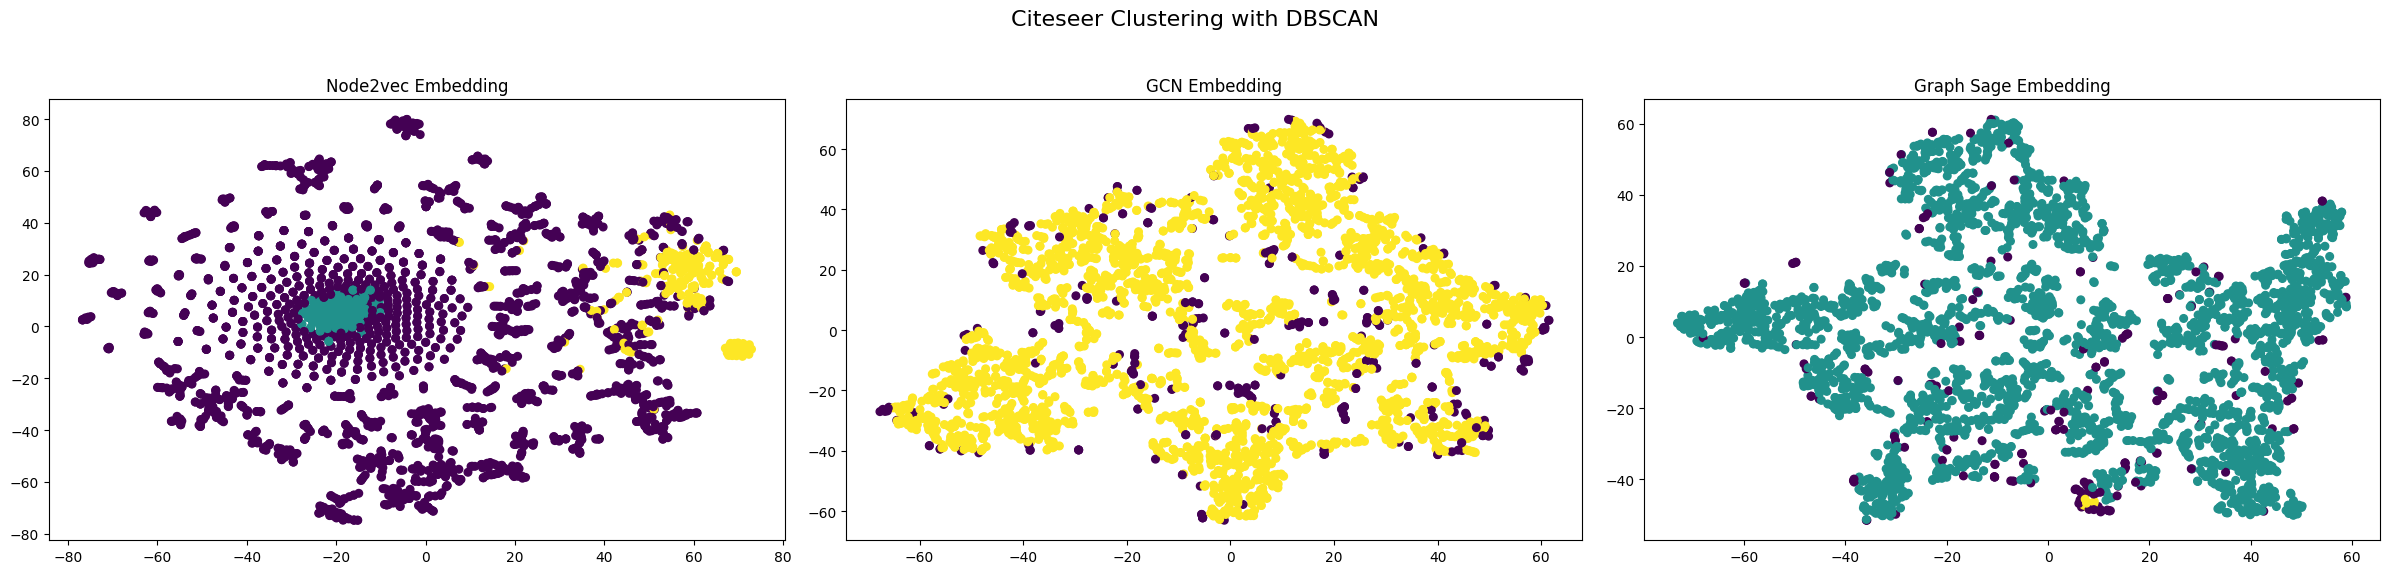

In [259]:
plotResults(name="Citeseer Clustering with DBSCAN",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

### Spectral

In [261]:
sc = SpectralClustering(n_clusters=6, affinity='nearest_neighbors', random_state=42)
predictionsN2vCite3=sc.fit_predict(embeddingsN2vCite)
predictionsGCNCite3=sc.fit_predict(embeddingsGCN_cite)
predictionsSageCite3=sc.fit_predict(embeddingsSageCite)

predictions_list.clear()
predictions_list=[predictionsN2vCite3,predictionsGCNCite3,predictionsSageCite3]

c:\Users\Dell\anaconda3\envs\node2vec-env\lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [263]:
results_citeseer.loc[len(results_citeseer)]=scores2("Spectral","Node2Vec",true_labels,predictionsN2vCite3,embeddingsN2vCite)
results_citeseer.loc[len(results_citeseer)]=scores2("Spectral","GCN",true_labels,predictionsGCNCite3,embeddingsGCN_cite)
results_citeseer.loc[len(results_citeseer)]=scores2("Spectral","Graph Sage",true_labels,predictionsSageCite3,embeddingsSageCite)

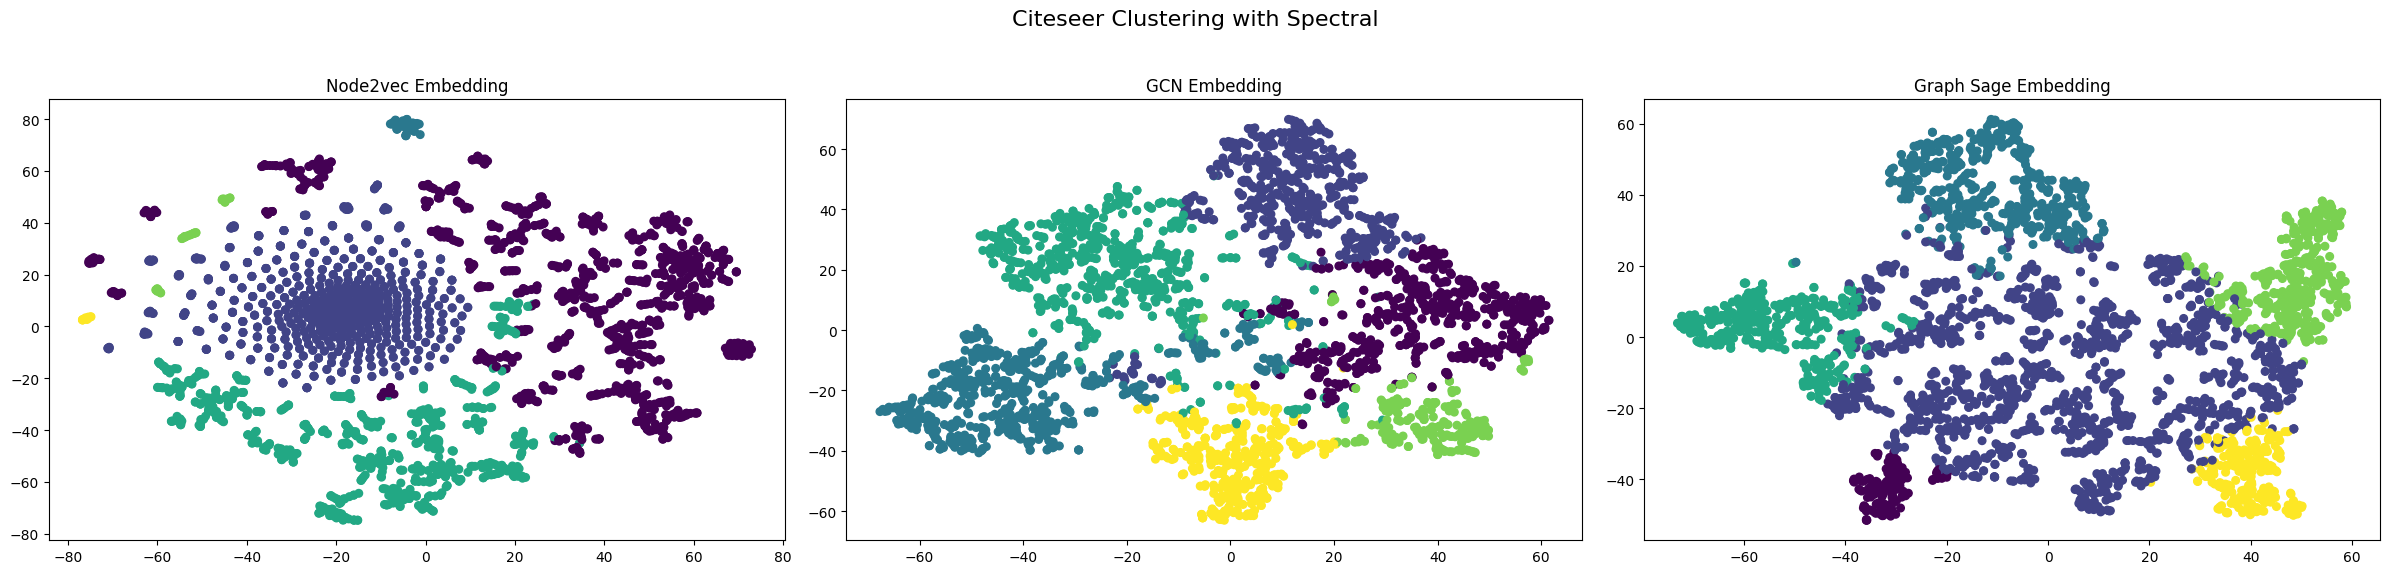

In [264]:
plotResults(name="Citeseer Clustering with Spectral",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

### Gaussian Mixture Model

In [272]:
gmm = GaussianMixture(n_components=6, covariance_type='full', random_state=42)
predictionsN2vCite4=gmm.fit_predict(embeddingsN2vCite)
predictionsGCNCite4=gmm.fit_predict(embeddingsGCN_cite)
predictionsSageCite4=gmm.fit_predict(embeddingsSageCite)

predictions_list.clear()
predictions_list=[predictionsN2vCite4,predictionsGCNCite4,predictionsSageCite4]

In [267]:
results_citeseer.loc[len(results_citeseer)]=scores2("GMM","Node2Vec",true_labels,predictionsN2vCite3,embeddingsN2vCite)
results_citeseer.loc[len(results_citeseer)]=scores2("GMM","GCN",true_labels,predictionsGCNCite3,embeddingsGCN_cite)
results_citeseer.loc[len(results_citeseer)]=scores2("GMM","Graph Sage",true_labels,predictionsSageCite3,embeddingsSageCite)

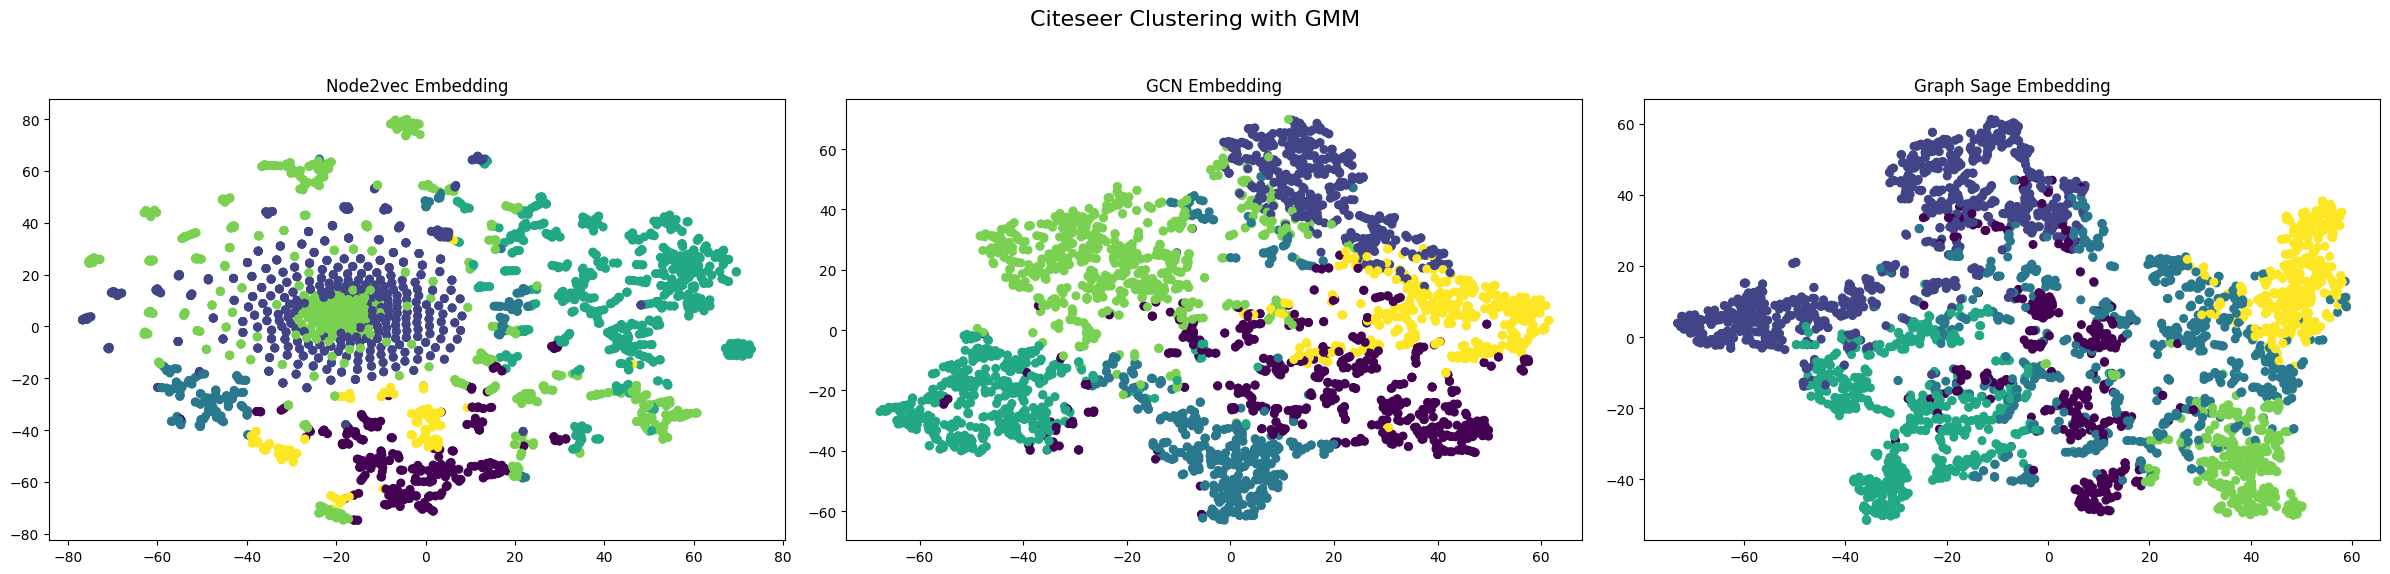

In [273]:
plotResults(name="Citeseer Clustering with GMM",embeddings_list=embeddings_list,predictions_list=predictions_list,methods=methods)

# Οπτικοποίηση embeddings

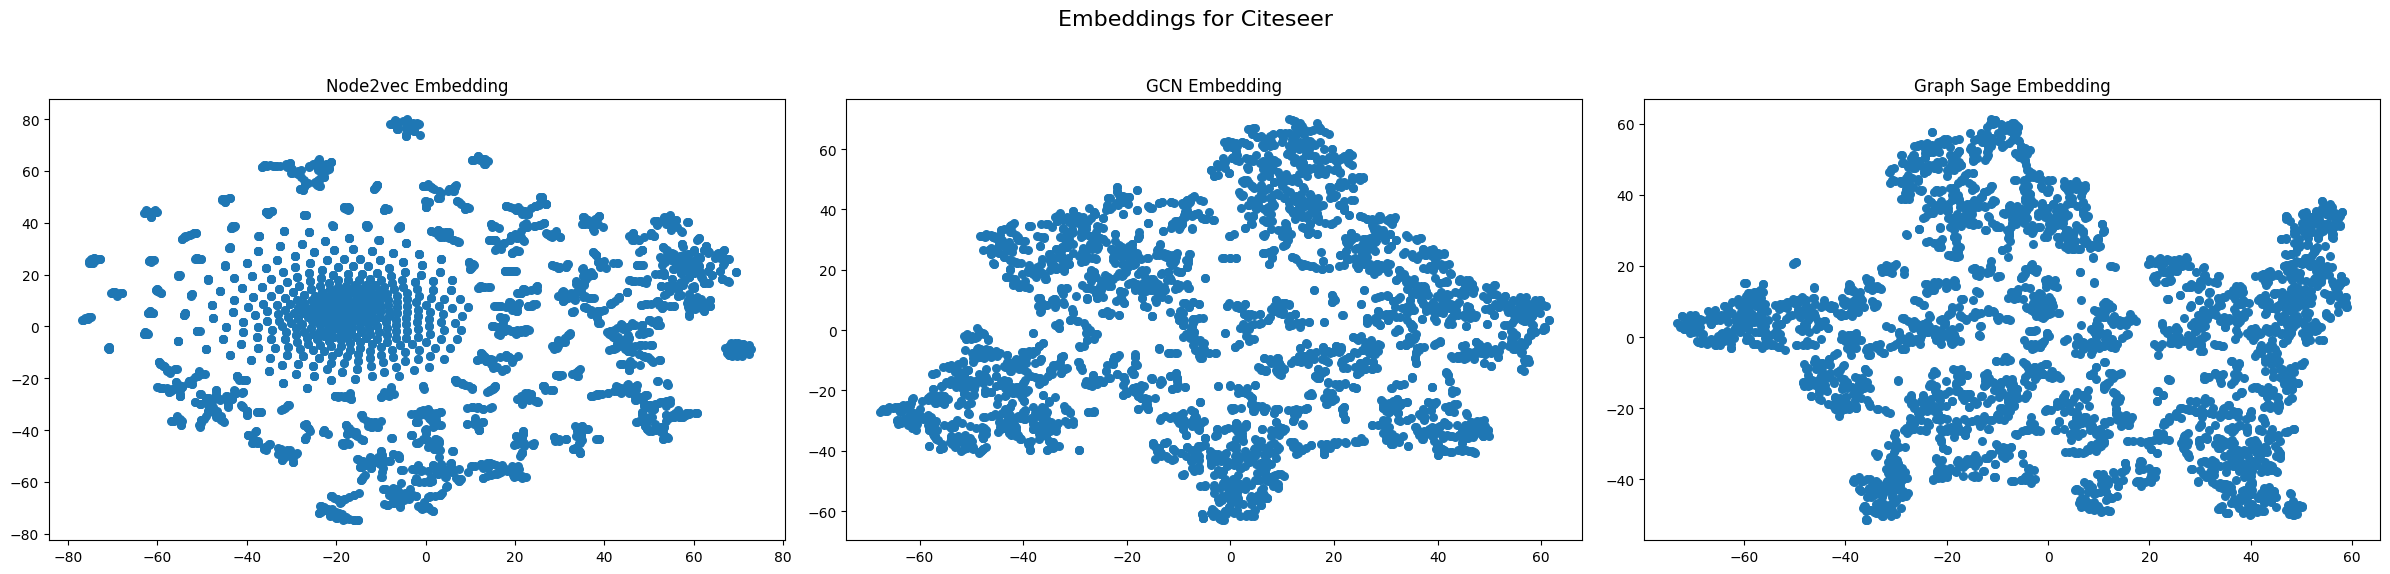

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle("Embeddings for Citeseer", fontsize=16)
        
for i in range(3):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings_list[i])
    axes[i].scatter(reduced[:, 0], reduced[:, 1],c=None, s=30)
    axes[i].set_title(f'{methods[i]} Embedding')
        
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()            

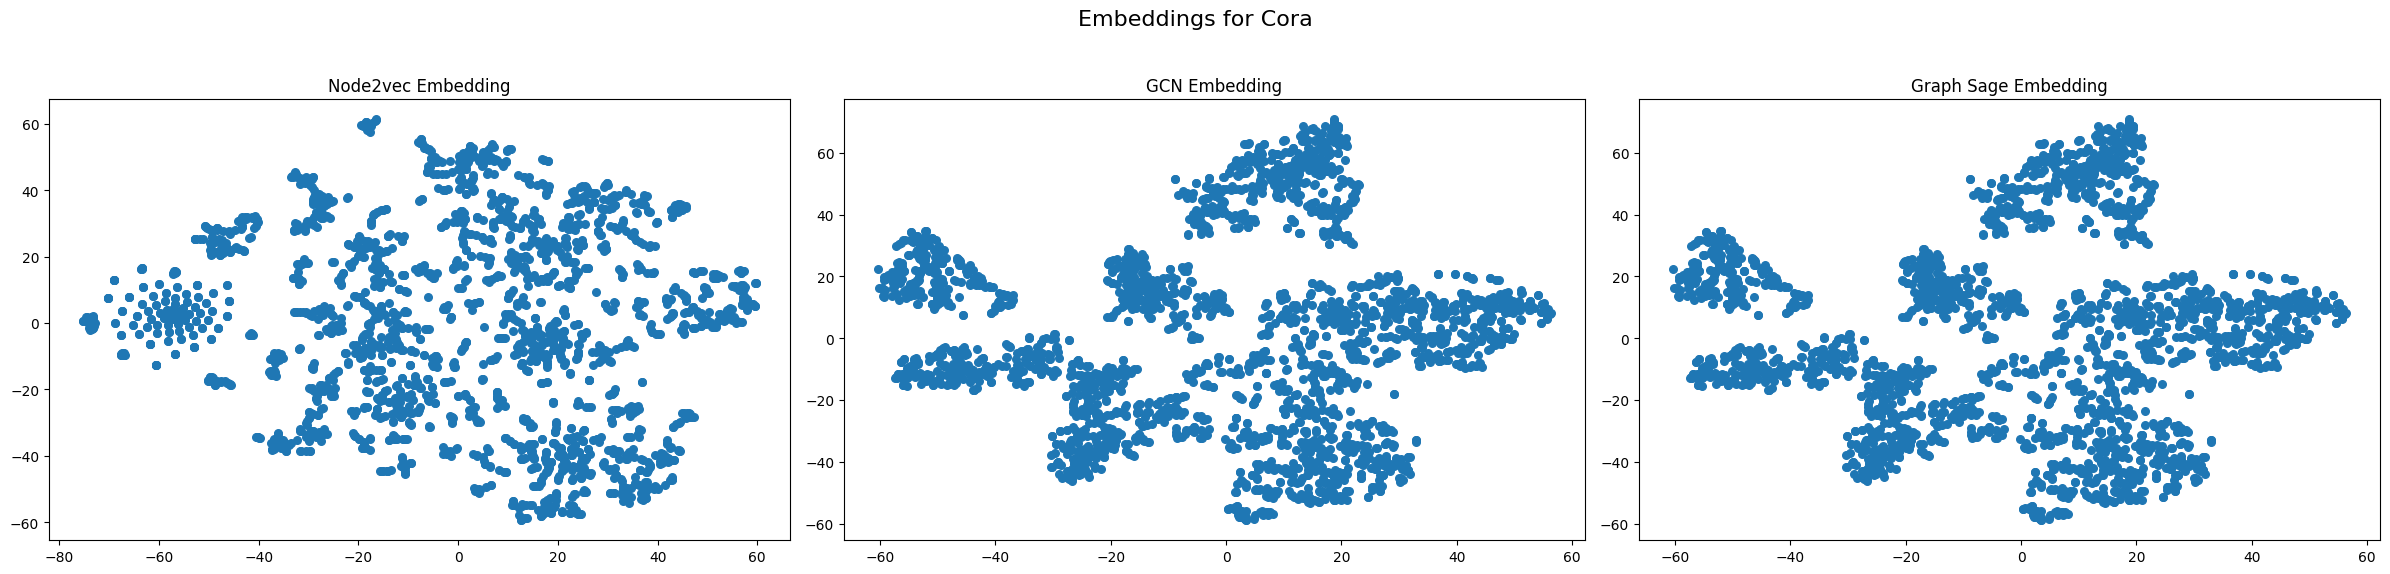

In [279]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle("Embeddings for Cora", fontsize=16)
        
for i in range(3):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings_list[i])
    axes[i].scatter(reduced[:, 0], reduced[:, 1],c=None, s=30)
    axes[i].set_title(f'{methods[i]} Embedding')
        
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() 

# Αποτελέσματα

In [265]:
results_citeseer

,Embeddings type,Clustering,Silhouette Score,ARI,NMI
0,kmeans,Node2Vec,0.05,0.16,0.21
1,kmeans,GCN,0.33,0.38,0.37
2,kmeans,Graph Sage,0.23,0.30,0.35
3,DBSCAN,Node2Vec,-0.18,0.01,0.06
4,DBSCAN,GCN,0.17,0.00,0.00
5,DBSCAN,Graph Sage,0.10,0.00,0.01
6,Spectral,Node2Vec,0.02,0.12,0.16
7,Spectral,GCN,0.32,0.39,0.38
8,Spectral,Graph Sage,0.25,0.18,0.36


In [234]:
results_cora

,Embeddings type,Clustering,Silhouette Score,ARI,NMI
0,kmeans,Node2Vec,0.08,0.36,0.43
1,kmeans,GCN,0.40,0.59,0.60
2,kmeans,Graph Sage,0.42,0.60,0.60
3,DBSCAN,Node2Vec,0.20,-0.01,0.01
4,DBSCAN,GCN,0.58,0.00,0.00
5,DBSCAN,Graph Sage,-0.15,0.01,0.02
6,Spectral,Node2Vec,0.06,-0.00,0.13
7,Spectral,GCN,0.40,0.63,0.64
8,Spectral,Graph Sage,0.41,0.63,0.63
9,GMM,Node2Vec,0.08,0.36,0.43


Τρεις Μετρικές Αξιολόγησης:

--Silhouette Score: Πόσο καλά χωρίζονται τα clusters (γεωμετρικά).

--ARI (Adjusted Rand Index): Συμφωνία με ground truth labels.

--NMI (Normalized Mutual Information): Ομοιότητα μεταξύ clustering και ground truth.

| Μοντέλο Embedding  | Απόδοση                                           |
| -----------------  | --------------------------------------------------|
| **GraphSAGE**      | Σταθερά υψηλά ARI/NMI                             |
| **GCN**            | Καλά αποτελέσματα σε combination με Spectral/GMM  |
| **Node2Vec**       | Υποδεέστερος γενικά σε ARI/NMI                    |




| Clustering Μέθοδος | Σχόλια                                            |
| ------------------ | ------------------------------------------------- |
| **k-means**        | Απλός αλλά αποτελεσματικός                        |
| **DBSCAN**         | Πολύ ασταθής — υψηλό Silhouette αλλά μηδενικό ARI |
| **Spectral**       | Καλή ισορροπία με GCN/GraphSAGE                   |
| **GMM**            | Σταθερός, καλή NMI/ARI με GraphSAGE               |


Γενική Εκτίμηση

Η δομή των Cora και Citeseer χαρακτηρίζεται από:

--Τοπική συνοχή, αλλά χωρίς ξεκάθαρη παγκόσμια δομή,

--Μη γραμμικότητα και επικάλυψη μεταξύ κατηγοριών,

--Ποικιλία πυκνότητας ανά περιοχή του γράφου.

Καθώς η πληροφορία είναι εν μέρει εγγεγραμμένη στη δομή, η χρήση σύνθετων embeddings (όπως GraphSAGE) σε συνδυασμό με ευέλικτους αλγορίθμους clustering (GMM, Spectral Clustering) αποδίδει καλύτερα.